In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

In [2]:
# Load the dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1761s 10us/step


In [3]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [4]:
# Class names in CIFAR-10

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

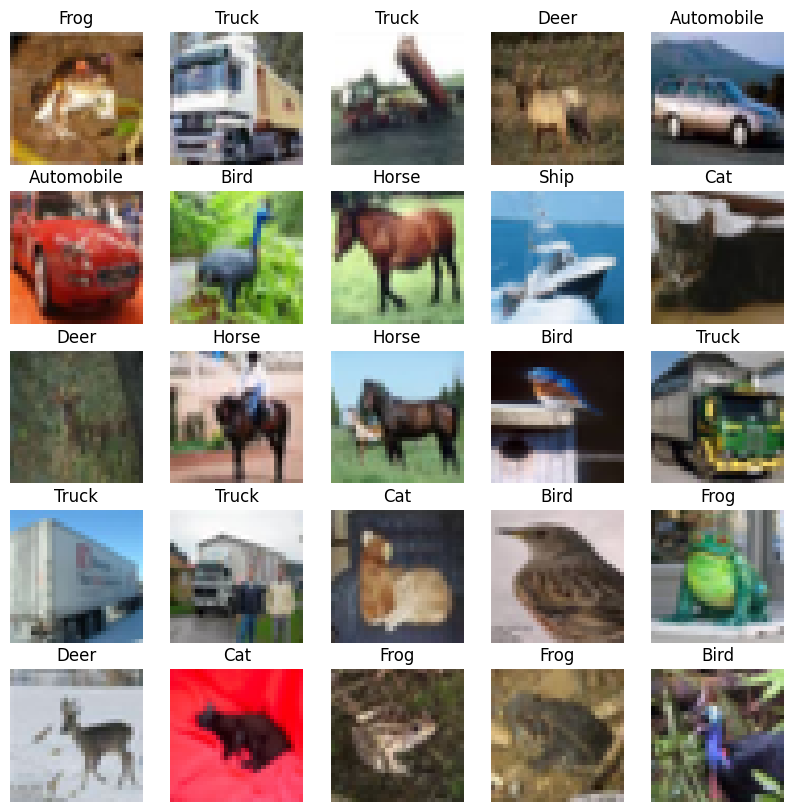

In [5]:
# Display the first 25 images

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

plt.show()

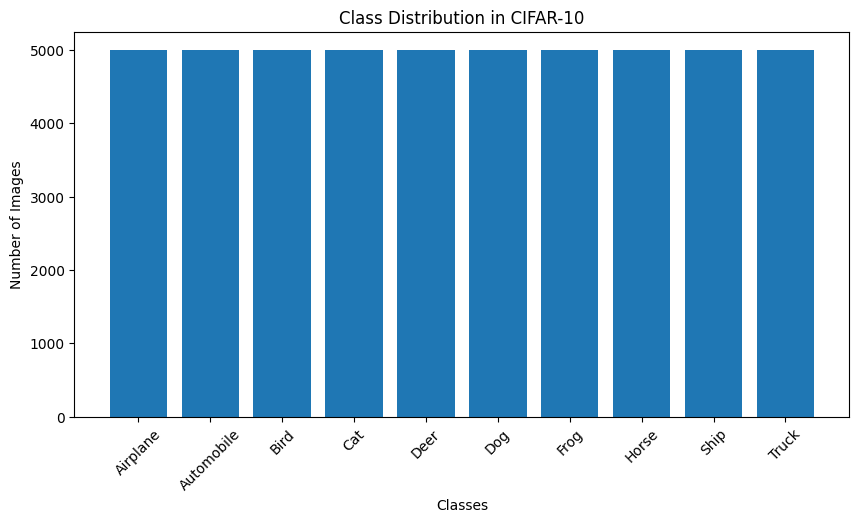

In [6]:
# Count images in each class

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.xticks(rotation=45)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.title("Class Distribution in CIFAR-10")

plt.show()

In [7]:
# Normalize pixel values

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [8]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [9]:
# Create the CNN model

model = models.Sequential()

In [10]:
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(32,32,3)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(layers.MaxPooling2D(pool_size=(2,2)))

In [12]:
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

In [13]:
model.add(layers.MaxPooling2D(pool_size=(2,2)))

In [14]:
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

In [15]:
model.add(layers.Flatten())

In [16]:
model.add(layers.Dense(
    64,
    activation='relu'
))

In [17]:
model.add(layers.Dense(
    10,
    activation='softmax'
))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.4835 - loss: 1.4343 - val_accuracy: 0.5480 - val_loss: 1.2755
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.5793 - loss: 1.1901 - val_accuracy: 0.5994 - val_loss: 1.1376
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.6255 - loss: 1.0637 - val_accuracy: 0.6280 - val_loss: 1.0634
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6549 - loss: 0.9733 - val_accuracy: 0.6539 - val_loss: 0.9945
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.6809 - loss: 0.9080 - val_accuracy: 0.6782 - val_loss: 0.9259


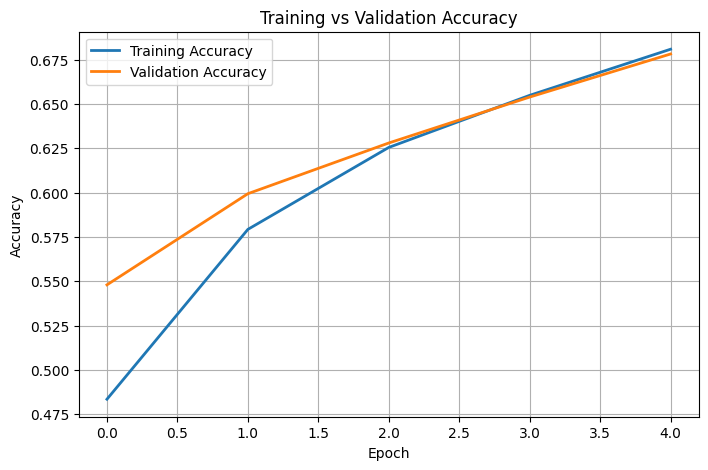

In [23]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

# Save Figure
plt.savefig(
    "training_validation_accuracy.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

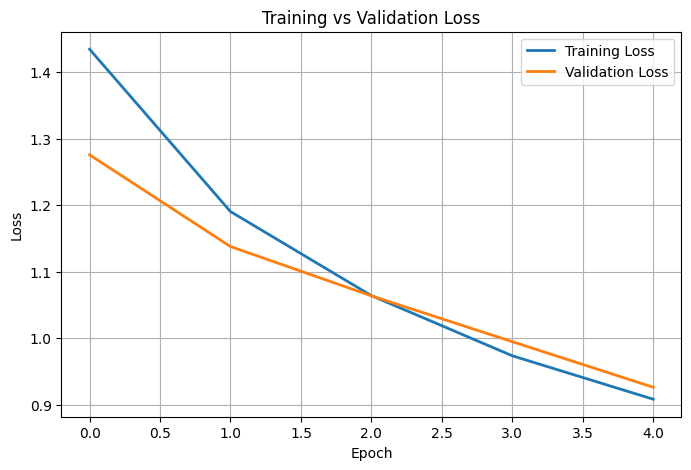

In [24]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.savefig(
    "training_validation_loss.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [25]:
# Evaluate on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6782 - loss: 0.9259
Test Loss : 0.9259390830993652
Test Accuracy : 0.6782000064849854


In [26]:
# Make predictions

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


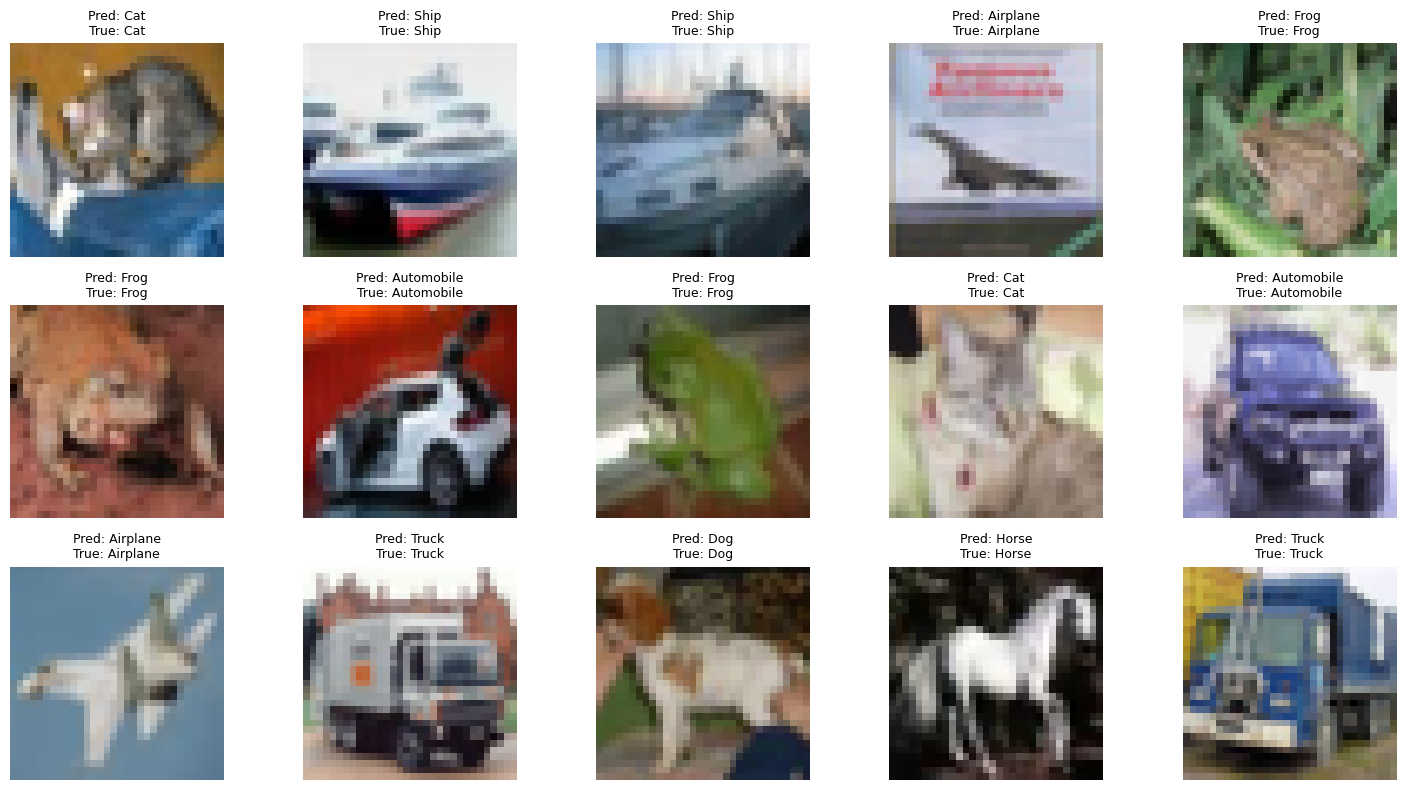

In [27]:
plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

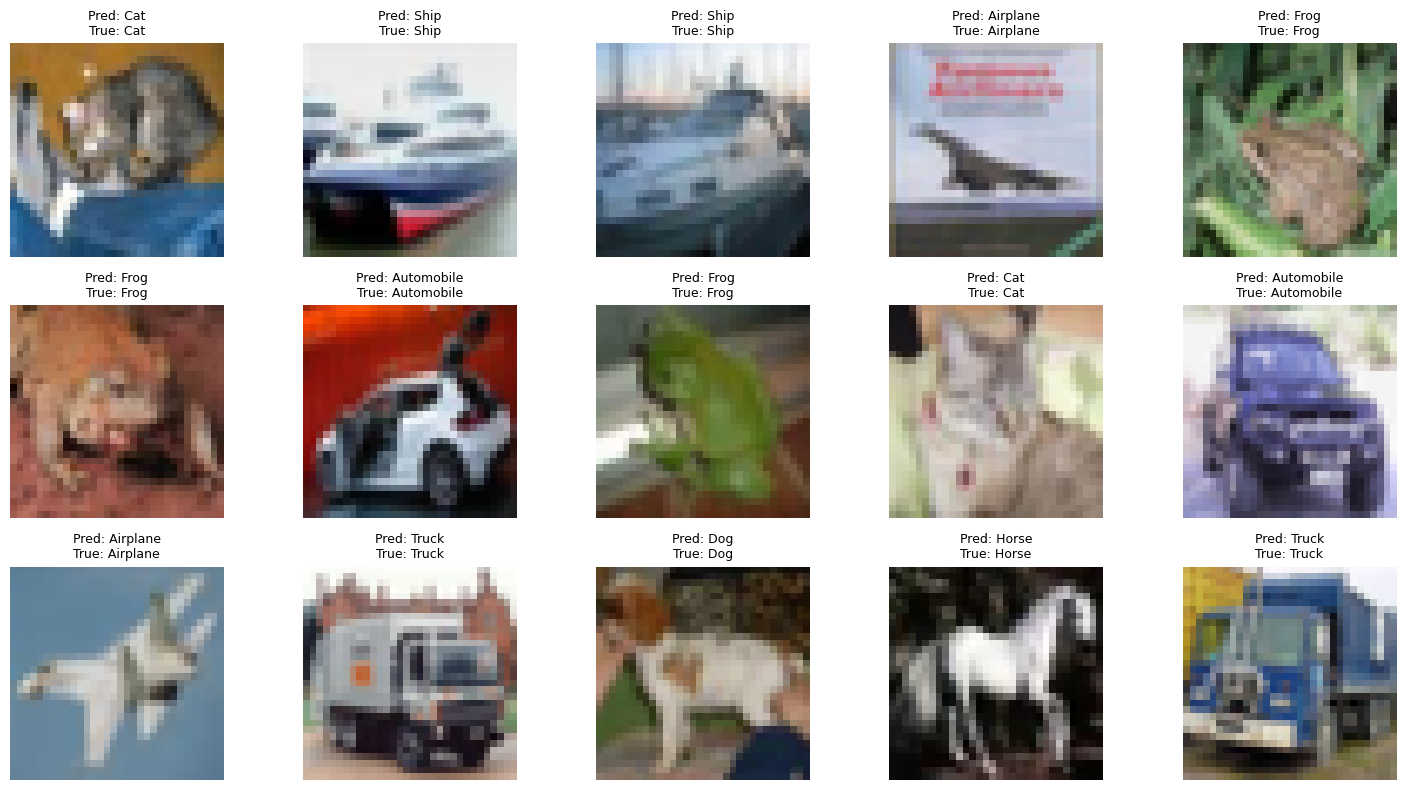

In [28]:
plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

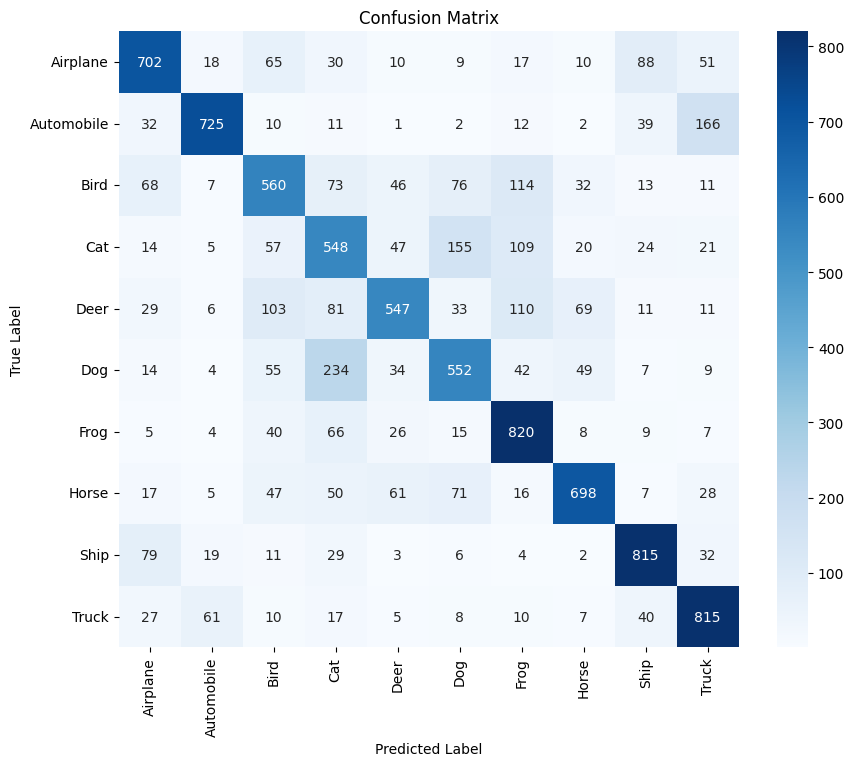

In [29]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [30]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.71      0.70      0.71      1000
  Automobile       0.85      0.72      0.78      1000
        Bird       0.58      0.56      0.57      1000
         Cat       0.48      0.55      0.51      1000
        Deer       0.70      0.55      0.61      1000
         Dog       0.60      0.55      0.57      1000
        Frog       0.65      0.82      0.73      1000
       Horse       0.78      0.70      0.74      1000
        Ship       0.77      0.81      0.79      1000
       Truck       0.71      0.81      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



In [31]:
precision = precision_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

recall = recall_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

f1 = f1_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.6836734505076398
Recall    : 0.6782
F1 Score  : 0.6775846160514608


In [32]:
print("Trainable Parameters\n")

for layer in model.layers:

    print(f"{layer.name}")

    print("Trainable Parameters :", layer.count_params())

    print("-"*40)

Trainable Parameters

conv2d
Trainable Parameters : 896
----------------------------------------
max_pooling2d
Trainable Parameters : 0
----------------------------------------
conv2d_1
Trainable Parameters : 18496
----------------------------------------
max_pooling2d_1
Trainable Parameters : 0
----------------------------------------
conv2d_2
Trainable Parameters : 36928
----------------------------------------
flatten
Trainable Parameters : 0
----------------------------------------
dense
Trainable Parameters : 65600
----------------------------------------
dense_1
Trainable Parameters : 650
----------------------------------------


In [35]:
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
)

feature_maps = feature_model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


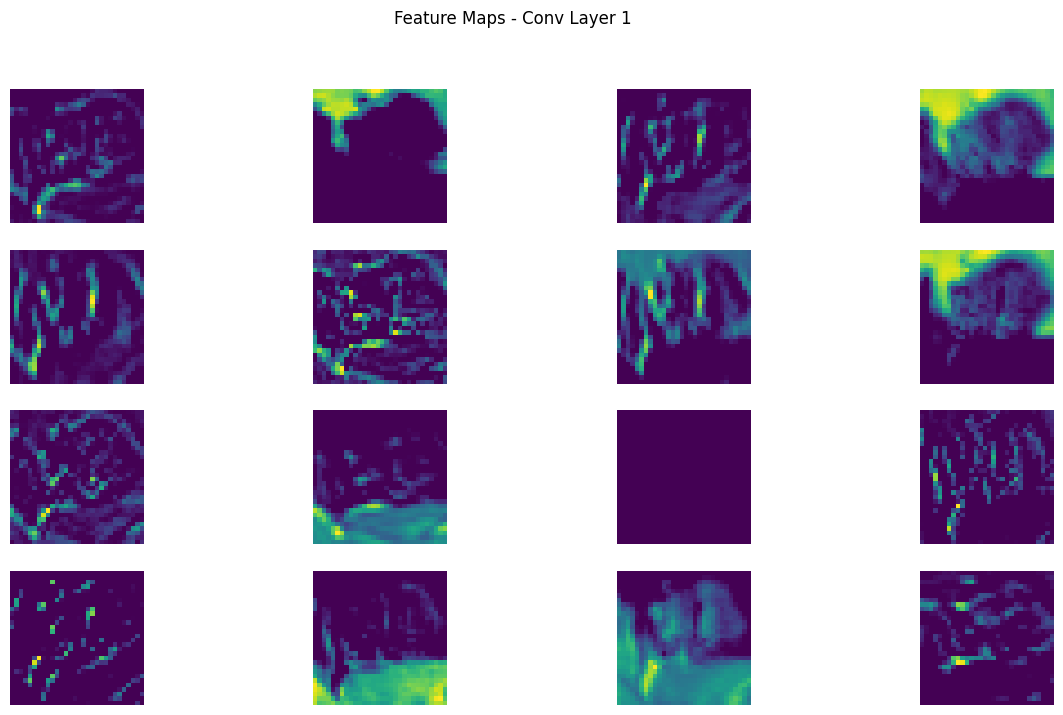

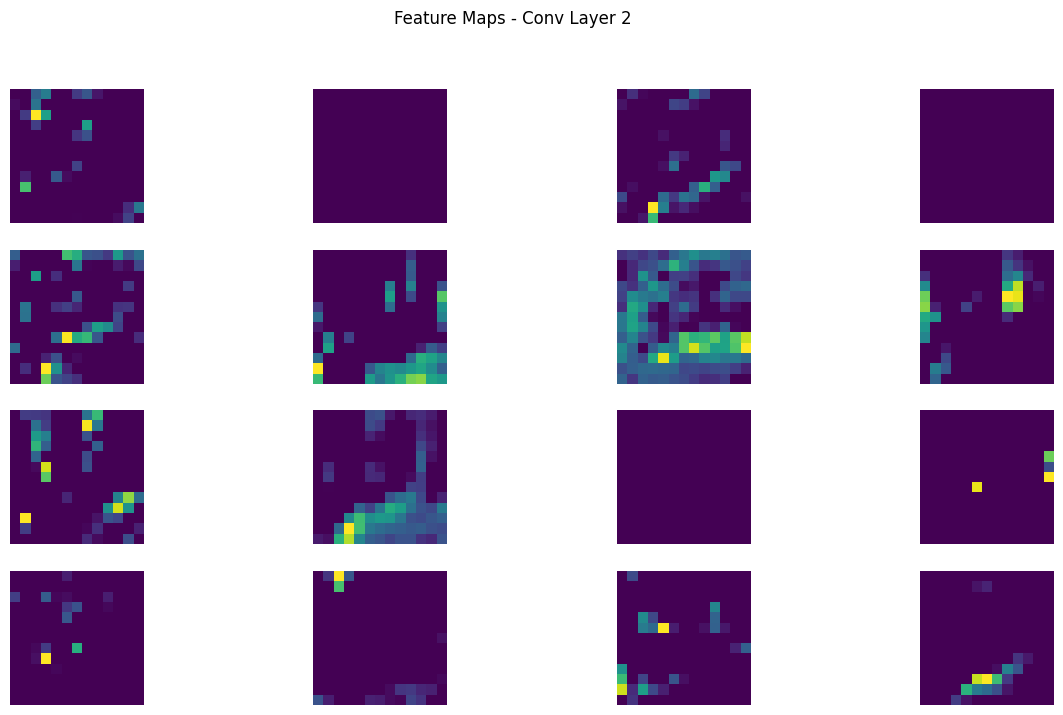

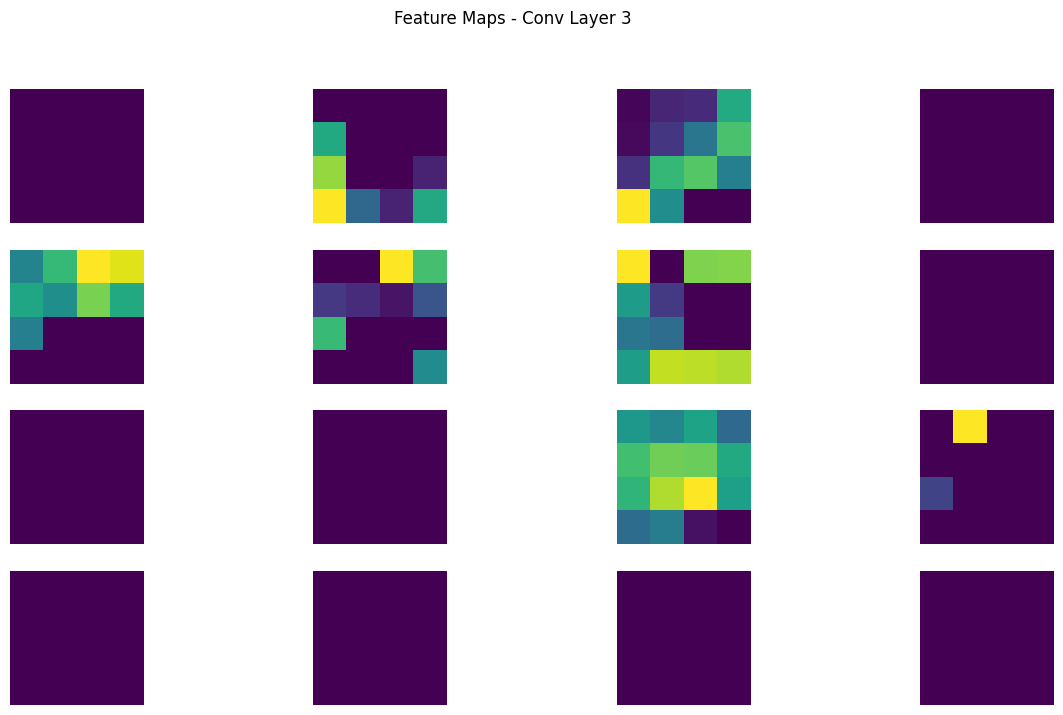

In [36]:
for layer_num, feature_map in enumerate(feature_maps):

    plt.figure(figsize=(15,8))

    n_features = min(16, feature_map.shape[-1])

    for i in range(n_features):

        plt.subplot(4,4,i+1)
        plt.imshow(feature_map[0,:,:,i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Feature Maps - Conv Layer {layer_num+1}")

    plt.savefig(
        f"feature_map_layer_{layer_num+1}.eps",
        format='eps',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()

In [38]:
# Average Pooling Model

avg_model = models.Sequential()

avg_model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
avg_model.add(layers.AveragePooling2D((2,2)))

avg_model.add(layers.Conv2D(64,(3,3),activation='relu'))
avg_model.add(layers.AveragePooling2D((2,2)))

avg_model.add(layers.Conv2D(64,(3,3),activation='relu'))

avg_model.add(layers.Flatten())

avg_model.add(layers.Dense(64,activation='relu'))

avg_model.add(layers.Dense(10,activation='softmax'))

avg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

avg_history = avg_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.4145 - loss: 1.5995 - val_accuracy: 0.5101 - val_loss: 1.3585
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 77ms/step - accuracy: 0.5457 - loss: 1.2729 - val_accuracy: 0.5641 - val_loss: 1.2217
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.6040 - loss: 1.1196 - val_accuracy: 0.6161 - val_loss: 1.0813
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.6413 - loss: 1.0172 - val_accuracy: 0.6391 - val_loss: 1.0043
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.6704 - loss: 0.9384 - val_accuracy: 0.6563 - val_loss: 0.9695


In [39]:
sgd_model = tf.keras.models.clone_model(model)

sgd_model.build((None,32,32,3))

sgd_model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sgd_history = sgd_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 88ms/step - accuracy: 0.2160 - loss: 2.1397 - val_accuracy: 0.2636 - val_loss: 2.0268
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.3175 - loss: 1.8808 - val_accuracy: 0.3668 - val_loss: 1.7744
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.3892 - loss: 1.6968 - val_accuracy: 0.3802 - val_loss: 1.6696
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.4372 - loss: 1.5617 - val_accuracy: 0.4600 - val_loss: 1.4952
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.4707 - loss: 1.4721 - val_accuracy: 0.4672 - val_loss: 1.4630


In [40]:
kernel_model = models.Sequential()

kernel_model.add(layers.Conv2D(
    32,
    (5,5),
    activation='relu',
    input_shape=(32,32,3)
))

kernel_model.add(layers.MaxPooling2D((2,2)))

kernel_model.add(layers.Conv2D(64,(5,5),activation='relu'))

kernel_model.add(layers.MaxPooling2D((2,2)))

kernel_model.add(layers.Flatten())

kernel_model.add(layers.Dense(64,activation='relu'))

kernel_model.add(layers.Dense(10,activation='softmax'))

kernel_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

kernel_history = kernel_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 122ms/step - accuracy: 0.4470 - loss: 1.5284 - val_accuracy: 0.5553 - val_loss: 1.2609
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 120ms/step - accuracy: 0.5893 - loss: 1.1691 - val_accuracy: 0.6090 - val_loss: 1.1329
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 116ms/step - accuracy: 0.6434 - loss: 1.0192 - val_accuracy: 0.6300 - val_loss: 1.0803
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.6795 - loss: 0.9267 - val_accuracy: 0.6663 - val_loss: 0.9682
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.7030 - loss: 0.8498 - val_accuracy: 0.6739 - val_loss: 0.9379
